# Challenge 2 — Hacia el agua limpia para todos
## Parte 1 V2: SVM-RBF, ablaciones y Optuna

Esta versión busca mejorar la línea base clásica sin inflar las métricas mediante
fuga de información. Incorpora:

- un **nuevo holdout de auditoría**, porque el test de la V1 ya fue observado;
- búsqueda conjunta de imputación, escalado, balanceo, `C` y `gamma`;
- Optuna con validación estratificada repetida;
- optimización de hiperparámetros por `average_precision`;
- ajuste posterior del umbral mediante predicciones *out-of-fold*;
- un umbral orientado a F1 y otro que exige una especificidad mínima;
- comparación contra la configuración V1 usando solamente entrenamiento;
- extracción congelada de 64 muestras reales para la futura QSVM.

> El test no participa en imputación, escalado, balanceo, selección de
> hiperparámetros ni selección del umbral.

## 0. Fundamento metodológico

El kernel RBF se define como:

\[
K(\mathbf{x}_i,\mathbf{x}_j)=
\exp(-\gamma\|\mathbf{x}_i-\mathbf{x}_j\|^2)
\]

`C` controla la penalización de errores y `gamma` la complejidad local de la
frontera. Como el RBF y SMOTE dependen de distancias, el escalado debe ocurrir
antes del sobremuestreo.

La selección se divide en dos etapas:

1. **Modelo y representación:** maximizar `average_precision`, independiente de
   un umbral fijo.
2. **Decisión:** seleccionar un umbral con scores OOF de entrenamiento.

Secuencia oficial:

```text
split original → CV de entrenamiento → imputación → escalado → balanceo
→ SVM-RBF → umbral OOF → evaluación única del holdout
```

## 1. Instalación e importaciones

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
%pip install -q -U imbalanced-learn optuna kagglehub joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 8.1 MB/s eta 0:00:00


In [3]:
from __future__ import annotations

import json
import platform
import sys
import warnings
from collections import Counter
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import sklearn
import imblearn

from IPython.display import display
from optuna.samplers import TPESampler
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.svm import SVC
from imblearn import FunctionSampler
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import BorderlineSMOTE, SMOTE
from imblearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

print('Python:', sys.version.split()[0])
print('scikit-learn:', sklearn.__version__)
print('imbalanced-learn:', imblearn.__version__)
print('Optuna:', optuna.__version__)

Python: 3.12.13
scikit-learn: 1.6.1
imbalanced-learn: 0.14.2
Optuna: 4.9.0


## 2. Configuración reproducible

In [4]:
SEED = 42
AUDIT_TEST_SEED = 20260721
QUANTUM_SEED = 42
TARGET = 'Potability'
TEST_SIZE = 0.20
N_SPLITS = 5
N_JOBS = -1

FEATURES = [
    'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
    'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity',
]
MISSING_COLUMNS = ['ph', 'Sulfate', 'Trihalomethanes']

ARTIFACT_DIR = Path('/content/drive/MyDrive/Colab Notebooks/artifacts_v2')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# quick: prueba funcional | balanced: recomendado | full: más estable
EXPERIMENT_MODE = 'balanced'
MODE_CONFIG = {
    'quick': {'n_trials': 20, 'search_repeats': 1, 'top_k': 4, 'threshold_repeats': 2},
    'balanced': {'n_trials': 50, 'search_repeats': 2, 'top_k': 6, 'threshold_repeats': 3},
    'full': {'n_trials': 100, 'search_repeats': 4, 'top_k': 10, 'threshold_repeats': 5},
}
CFG = MODE_CONFIG[EXPERIMENT_MODE]

STABILITY_PENALTY = 0.10
MIN_SAFETY_SPECIFICITY = 0.70

print(json.dumps({'mode': EXPERIMENT_MODE, **CFG}, indent=2))

{
  "mode": "balanced",
  "n_trials": 50,
  "search_repeats": 2,
  "top_k": 6,
  "threshold_repeats": 3
}


## 3. Carga robusta del dataset

In [5]:
def resolve_dataset_path() -> Path:
    candidates = [
        Path('/content/water_potability.csv'),
        Path('/content/drive/MyDrive/water_potability.csv'),
        Path('/mnt/data/water_potability.csv'),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    try:
        import kagglehub
        dataset_dir = Path(kagglehub.dataset_download('adityakadiwal/water-potability'))
        matches = list(dataset_dir.rglob('water_potability.csv'))
        if matches:
            return matches[0]
    except Exception as exc:
        print('KaggleHub no pudo resolver el archivo:', repr(exc))

    raise FileNotFoundError(
        'No se encontró water_potability.csv. Súbelo a /content o monta Drive.'
    )

DATA_PATH = resolve_dataset_path()
df = pd.read_csv(DATA_PATH)
print('Archivo:', DATA_PATH)
print('Forma:', df.shape)
display(df.head())

Using Colab cache for faster access to the 'water-potability' dataset.
Archivo: /kaggle/input/water-potability/water_potability.csv
Forma: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 4. Auditoría inicial

In [6]:
EXPECTED_COLUMNS = FEATURES + [TARGET]
assert list(df.columns) == EXPECTED_COLUMNS
assert df[TARGET].notna().all()
assert set(df[TARGET].unique()).issubset({0, 1})
assert df.duplicated().sum() == 0

missing_table = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (100 * df.isna().mean()).round(2),
})
class_table = df[TARGET].value_counts().sort_index().to_frame('count')
class_table['percentage'] = (100 * class_table['count'] / len(df)).round(2)

display(missing_table)
display(class_table)

assert df['ph'].isna().sum() == 491
assert df['Sulfate'].isna().sum() == 781
assert df['Trihalomethanes'].isna().sum() == 162

,dtype,missing,missing_pct
ph,float64,491,14.99
Hardness,float64,0,0.00
Solids,float64,0,0.00
Chloramines,float64,0,0.00
Sulfate,float64,781,23.84
Conductivity,float64,0,0.00
Organic_carbon,float64,0,0.00
Trihalomethanes,float64,162,4.95
Turbidity,float64,0,0.00
Potability,int64,0,0.00


,count,percentage
Potability,,
0,1998,60.99
1,1278,39.01


## 5. Nuevo holdout de auditoría

La V1 utilizó un test con semilla 42 y sus resultados ya fueron observados. Esta
V2 crea un nuevo holdout con semilla `20260721`. Después de ejecutar la evaluación
final, tampoco debe utilizarse este holdout para decidir nuevos cambios.

In [7]:
X = df[FEATURES].copy()
y = df[TARGET].astype(int).copy()

train_indices, test_indices = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=AUDIT_TEST_SEED,
)
X_train = X.loc[train_indices].copy()
X_test = X.loc[test_indices].copy()
y_train = y.loc[train_indices].copy()
y_test = y.loc[test_indices].copy()

assert set(X_train.index).isdisjoint(X_test.index)

split_summary = pd.DataFrame({
    'split': ['train_v2', 'audit_test_v2'],
    'n': [len(y_train), len(y_test)],
    'class_0': [(y_train == 0).sum(), (y_test == 0).sum()],
    'class_1': [(y_train == 1).sum(), (y_test == 1).sum()],
    'positive_pct': [100 * y_train.mean(), 100 * y_test.mean()],
})
display(split_summary.round(2))

locked_test = X_test.copy()
locked_test.insert(0, 'source_index', locked_test.index)
locked_test[TARGET] = y_test
locked_test.to_csv(ARTIFACT_DIR / 'audit_test_v2_locked.csv', index=False)

,split,n,class_0,class_1,positive_pct
0,train_v2,2620,1598,1022,39.01
1,audit_test_v2,656,400,256,39.02


## 6. Espacio de experimentación

Optuna compara:

- imputación por mediana, mediana + indicador, KNN y KNN + indicador;
- `StandardScaler`, `RobustScaler` y Yeo–Johnson;
- sin balanceo, pesos de clase, SMOTE, BorderlineSMOTE y SMOTETomek;
- `C` entre `1e-2` y `1e2`;
- `gamma` entre `1e-3` y `1`.

No se combinan pesos de clase con sobremuestreo para evitar doble compensación.

In [8]:
def build_pipeline(params: dict[str, Any], seed: int = SEED) -> Pipeline:
    imputer_name = params['imputer']
    if imputer_name == 'median':
        imputer = SimpleImputer(strategy='median', add_indicator=False)
    elif imputer_name == 'median_indicator':
        imputer = SimpleImputer(strategy='median', add_indicator=True)
    elif imputer_name == 'knn':
        imputer = KNNImputer(
            n_neighbors=int(params.get('knn_neighbors', 5)),
            weights=params.get('knn_weights', 'distance'),
            add_indicator=False,
        )
    elif imputer_name == 'knn_indicator':
        imputer = KNNImputer(
            n_neighbors=int(params.get('knn_neighbors', 5)),
            weights=params.get('knn_weights', 'distance'),
            add_indicator=True,
        )
    else:
        raise ValueError(f'Imputador desconocido: {imputer_name}')

    scaler_name = params['scaler']
    if scaler_name == 'standard':
        scaler = StandardScaler()
    elif scaler_name == 'robust':
        scaler = RobustScaler(quantile_range=(10, 90))
    elif scaler_name == 'power':
        scaler = PowerTransformer(method='yeo-johnson', standardize=True)
    else:
        raise ValueError(f'Escalador desconocido: {scaler_name}')

    balance_name = params['balance_strategy']
    class_weight = None
    if balance_name == 'none':
        sampler = FunctionSampler()
    elif balance_name == 'class_weight_balanced':
        sampler = FunctionSampler()
        class_weight = 'balanced'
    elif balance_name == 'class_weight_custom':
        sampler = FunctionSampler()
        class_weight = {0: 1.0, 1: float(params['positive_class_weight'])}
    elif balance_name == 'smote':
        sampler = SMOTE(
            sampling_strategy=float(params['sampling_strategy']),
            k_neighbors=int(params['smote_k_neighbors']),
            random_state=seed,
        )
    elif balance_name == 'borderline_smote':
        sampler = BorderlineSMOTE(
            sampling_strategy=float(params['sampling_strategy']),
            k_neighbors=int(params['smote_k_neighbors']),
            m_neighbors=10,
            kind='borderline-1',
            random_state=seed,
        )
    elif balance_name == 'smote_tomek':
        inner_smote = SMOTE(
            sampling_strategy=float(params['sampling_strategy']),
            k_neighbors=int(params['smote_k_neighbors']),
            random_state=seed,
        )
        sampler = SMOTETomek(smote=inner_smote, random_state=seed)
    else:
        raise ValueError(f'Balanceo desconocido: {balance_name}')

    svc = SVC(
        kernel='rbf',
        C=float(params['C']),
        gamma=float(params['gamma']),
        class_weight=class_weight,
        probability=False,
        cache_size=1500,
        random_state=seed,
    )

    return Pipeline([
        ('imputer', imputer),
        ('scaler', scaler),
        ('sampler', sampler),
        ('svc', svc),
    ])


def sample_trial_params(trial: optuna.Trial) -> dict[str, Any]:
    imputer = trial.suggest_categorical(
        'imputer', ['median', 'median_indicator', 'knn', 'knn_indicator']
    )
    if imputer.startswith('knn'):
        trial.suggest_int('knn_neighbors', 3, 15, step=2)
        trial.suggest_categorical('knn_weights', ['uniform', 'distance'])

    trial.suggest_categorical('scaler', ['standard', 'robust', 'power'])
    balance = trial.suggest_categorical(
        'balance_strategy',
        ['none', 'class_weight_balanced', 'class_weight_custom',
         'smote', 'borderline_smote', 'smote_tomek'],
    )
    if balance == 'class_weight_custom':
        trial.suggest_float('positive_class_weight', 1.05, 3.0, log=True)
    if balance in {'smote', 'borderline_smote', 'smote_tomek'}:
        # El ratio original ronda 0.64; el límite inferior evita pedir a SMOTE
        # una proporción menor a la existente.
        trial.suggest_float('sampling_strategy', 0.65, 1.0)
        trial.suggest_int('smote_k_neighbors', 3, 9, step=2)

    trial.suggest_float('C', 1e-2, 1e2, log=True)
    trial.suggest_float('gamma', 1e-3, 1.0, log=True)
    return dict(trial.params)

## 7. Optuna con validación estratificada repetida

In [9]:
search_cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=CFG['search_repeats'],
    random_state=SEED,
)
SEARCH_SPLITS = list(search_cv.split(X_train, y_train))
print('Folds por ensayo:', len(SEARCH_SPLITS))

Folds por ensayo: 10


In [10]:
def optuna_objective(trial: optuna.Trial) -> float:
    params = sample_trial_params(trial)
    fold_ap, fold_roc, fold_f1 = [], [], []

    try:
        for fold_number, (fit_pos, valid_pos) in enumerate(SEARCH_SPLITS):
            model = build_pipeline(params, seed=SEED + fold_number)
            model.fit(X_train.iloc[fit_pos], y_train.iloc[fit_pos])
            scores = model.decision_function(X_train.iloc[valid_pos])
            truth = y_train.iloc[valid_pos]

            fold_ap.append(average_precision_score(truth, scores))
            fold_roc.append(roc_auc_score(truth, scores))
            fold_f1.append(f1_score(truth, scores >= 0, zero_division=0))
    except (ValueError, FloatingPointError) as exc:
        trial.set_user_attr('failure', repr(exc))
        raise optuna.TrialPruned()

    mean_ap = float(np.mean(fold_ap))
    std_ap = float(np.std(fold_ap, ddof=1)) if len(fold_ap) > 1 else 0.0
    trial.set_user_attr('mean_average_precision', mean_ap)
    trial.set_user_attr('std_average_precision', std_ap)
    trial.set_user_attr('mean_roc_auc', float(np.mean(fold_roc)))
    trial.set_user_attr('mean_f1_default', float(np.mean(fold_f1)))
    return mean_ap - STABILITY_PENALTY * std_ap

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=SEED, multivariate=True, group=True),
    study_name='water_potability_svm_rbf_v2',
)
study.optimize(
    optuna_objective,
    n_trials=CFG['n_trials'],
    gc_after_trial=True,
    show_progress_bar=True,
)

print('Mejor score:', round(study.best_value, 5))
print(json.dumps(study.best_trial.params, indent=2))

trials_df = study.trials_dataframe(
    attrs=('number', 'value', 'params', 'user_attrs', 'state')
)
trials_df.to_csv(ARTIFACT_DIR / 'v2_optuna_trials.csv', index=False)

[I 2026-07-21 18:12:08,138] A new study created in memory with name: water_potability_svm_rbf_v2


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-21 18:12:21,139] Trial 0 finished with value: 0.5605065786629673 and parameters: {'imputer': 'median_indicator', 'scaler': 'standard', 'balance_strategy': 'borderline_smote', 'sampling_strategy': 0.7243186887373967, 'smote_k_neighbors': 3, 'C': 0.05415244119402541, 'gamma': 0.008179499475211672}. Best is trial 0 with value: 0.5605065786629673.
[I 2026-07-21 18:12:37,232] Trial 1 finished with value: 0.4371858945194543 and parameters: {'imputer': 'knn_indicator', 'knn_neighbors': 3, 'knn_weights': 'distance', 'scaler': 'robust', 'balance_strategy': 'smote', 'sampling_strategy': 0.9821099380386666, 'smote_k_neighbors': 9, 'C': 17.12337597316399, 'gamma': 0.008200518402245833}. Best is trial 0 with value: 0.5605065786629673.
[I 2026-07-21 18:12:46,834] Trial 2 finished with value: 0.5095690785956738 and parameters: {'imputer': 'median_indicator', 'scaler': 'power', 'balance_strategy': 'class_weight_balanced', 'C': 75.56810141274431, 'gamma': 0.2115429079726121}. Best is trial 0

## 8. Ajuste del umbral y estabilidad

In [11]:
def classification_metrics(y_true, scores, threshold: float) -> dict[str, float]:
    truth = np.asarray(y_true, dtype=int)
    pred = (np.asarray(scores) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(truth, pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        'threshold': float(threshold),
        'accuracy': accuracy_score(truth, pred),
        'precision': precision_score(truth, pred, zero_division=0),
        'recall': recall_score(truth, pred, zero_division=0),
        'f1': f1_score(truth, pred, zero_division=0),
        'specificity': specificity,
        'false_positive_rate': fp / (tn + fp) if (tn + fp) else np.nan,
        'balanced_accuracy': balanced_accuracy_score(truth, pred),
        'mcc': matthews_corrcoef(truth, pred),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }


def optimize_threshold(y_true, scores, min_specificity=None, n_grid=601):
    scores = np.asarray(scores, dtype=float)
    thresholds = np.unique(np.quantile(scores, np.linspace(0.005, 0.995, n_grid)))
    thresholds = np.unique(np.r_[thresholds, 0.0])
    rows = [classification_metrics(y_true, scores, t) for t in thresholds]
    if min_specificity is not None:
        constrained = [r for r in rows if r['specificity'] >= min_specificity]
        if constrained:
            rows = constrained
    return max(rows, key=lambda r: (r['f1'], r['specificity'], r['precision'], -abs(r['threshold'])))


def evaluate_candidate(params, name, trial_number, repeat_seeds):
    rows = []
    for repeat, repeat_seed in enumerate(repeat_seeds, start=1):
        cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=repeat_seed)
        scores = cross_val_predict(
            build_pipeline(params, seed=repeat_seed),
            X_train,
            y_train,
            cv=cv,
            method='decision_function',
            n_jobs=N_JOBS,
        )
        f1_choice = optimize_threshold(y_train, scores)
        safety_choice = optimize_threshold(
            y_train, scores, min_specificity=MIN_SAFETY_SPECIFICITY
        )
        row = {
            'candidate': name,
            'trial_number': trial_number,
            'repeat': repeat,
            'average_precision': average_precision_score(y_train, scores),
            'roc_auc': roc_auc_score(y_train, scores),
        }
        row.update({f'f1_{k}': v for k, v in f1_choice.items()})
        row.update({f'safety_{k}': v for k, v in safety_choice.items()})
        rows.append(row)
    return pd.DataFrame(rows)

In [12]:
completed = [
    t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE
]
top_trials = sorted(completed, key=lambda t: t.value, reverse=True)[:CFG['top_k']]
repeat_seeds = [SEED + 1000 + i for i in range(CFG['threshold_repeats'])]

stability_frames = []
for position, trial in enumerate(top_trials, start=1):
    print(f'Candidato {position}/{len(top_trials)}: trial {trial.number}')
    stability_frames.append(evaluate_candidate(
        dict(trial.params), f'optuna_trial_{trial.number}', trial.number, repeat_seeds
    ))

# Referencia V1 evaluada con los mismos folds y sin tocar el test.
V1_PARAMS = {
    'imputer': 'median',
    'scaler': 'standard',
    'balance_strategy': 'smote',
    'sampling_strategy': 1.0,
    'smote_k_neighbors': 5,
    'C': 1.0,
    'gamma': 1.0 / len(FEATURES),
}
stability_frames.append(evaluate_candidate(V1_PARAMS, 'v1_baseline', 'v1', repeat_seeds))

candidate_stability = pd.concat(stability_frames, ignore_index=True)
candidate_stability.to_csv(
    ARTIFACT_DIR / 'v2_candidate_stability_repeats.csv', index=False
)

summary = candidate_stability.groupby(['candidate', 'trial_number'], as_index=False).agg(
    mean_f1=('f1_f1', 'mean'),
    std_f1=('f1_f1', 'std'),
    mean_precision=('f1_precision', 'mean'),
    mean_recall=('f1_recall', 'mean'),
    mean_specificity=('f1_specificity', 'mean'),
    mean_average_precision=('average_precision', 'mean'),
    mean_roc_auc=('roc_auc', 'mean'),
    median_f1_threshold=('f1_threshold', 'median'),
    mean_safety_f1=('safety_f1', 'mean'),
    mean_safety_specificity=('safety_specificity', 'mean'),
    median_safety_threshold=('safety_threshold', 'median'),
)
display(summary.sort_values('mean_f1', ascending=False).round(4))
summary.to_csv(ARTIFACT_DIR / 'v2_candidate_summary.csv', index=False)

eligible = summary[summary['candidate'] != 'v1_baseline'].sort_values(
    ['mean_f1', 'std_f1', 'mean_average_precision'],
    ascending=[False, True, False],
)
selected_trial_number = int(eligible.iloc[0]['trial_number'])
selected_trial = next(t for t in completed if t.number == selected_trial_number)
selected_params = dict(selected_trial.params)
selected_f1_threshold = float(eligible.iloc[0]['median_f1_threshold'])
selected_safety_threshold = float(eligible.iloc[0]['median_safety_threshold'])

print('Trial seleccionado:', selected_trial_number)
print('Umbral F1:', selected_f1_threshold)
print('Umbral seguridad:', selected_safety_threshold)
print(json.dumps(selected_params, indent=2))

Candidato 1/6: trial 46
Candidato 2/6: trial 23
Candidato 3/6: trial 31
Candidato 4/6: trial 35
Candidato 5/6: trial 33
Candidato 6/6: trial 20


,candidate,trial_number,mean_f1,std_f1,mean_precision,mean_recall,mean_specificity,mean_average_precision,mean_roc_auc,median_f1_threshold,mean_safety_f1,mean_safety_specificity,median_safety_threshold
0,optuna_trial_20,20,0.5900,0.0045,0.4471,0.8673,0.3139,0.5772,0.6737,-0.9740,0.5388,0.7084,-0.2399
6,v1_baseline,v1,0.5886,0.0020,0.4529,0.8412,0.3494,0.5673,0.6682,-0.5921,0.5265,0.7032,0.1202
2,optuna_trial_31,31,0.5876,0.0011,0.4386,0.8940,0.2651,0.5843,0.6690,-1.1108,0.5357,0.7005,-0.7331
1,optuna_trial_23,23,0.5869,0.0030,0.4295,0.9276,0.2109,0.5862,0.6689,-1.1120,0.5307,0.7105,-0.7621
3,optuna_trial_33,33,0.5867,0.0006,0.4286,0.9299,0.2071,0.5814,0.6671,-1.1572,0.5291,0.7088,-0.6516
5,optuna_trial_46,46,0.5839,0.0023,0.4327,0.8995,0.2445,0.5841,0.6681,-1.0731,0.5378,0.7084,-0.7460
4,optuna_trial_35,35,0.5837,0.0014,0.4371,0.8790,0.2756,0.5838,0.6720,-1.0572,0.5452,0.7034,-0.3715


Trial seleccionado: 20
Umbral F1: -0.973989492219218
Umbral seguridad: -0.2398795495559185
{
  "imputer": "median",
  "scaler": "power",
  "balance_strategy": "smote_tomek",
  "sampling_strategy": 0.8234281858502869,
  "smote_k_neighbors": 5,
  "C": 7.824520430340897,
  "gamma": 0.05564284242478379
}


## 9. Auditoría del ganador con umbral interno

La configuración seleccionada se evalúa en cinco folds externos. En cada fold,
el umbral se vuelve a seleccionar usando únicamente predicciones OOF del
subconjunto externo de entrenamiento. Esto audita la política de umbral sin
utilizar el holdout final.

In [13]:
def fixed_config_threshold_audit(params):
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 9000)
    rows = []
    for fold, (train_pos, valid_pos) in enumerate(outer_cv.split(X_train, y_train), start=1):
        X_outer_train, y_outer_train = X_train.iloc[train_pos], y_train.iloc[train_pos]
        X_outer_valid, y_outer_valid = X_train.iloc[valid_pos], y_train.iloc[valid_pos]

        inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED + fold)
        inner_scores = cross_val_predict(
            build_pipeline(params, seed=SEED + 100 + fold),
            X_outer_train,
            y_outer_train,
            cv=inner_cv,
            method='decision_function',
            n_jobs=N_JOBS,
        )
        threshold = optimize_threshold(y_outer_train, inner_scores)['threshold']
        model = build_pipeline(params, seed=SEED + 200 + fold)
        model.fit(X_outer_train, y_outer_train)
        valid_scores = model.decision_function(X_outer_valid)
        metrics = classification_metrics(y_outer_valid, valid_scores, threshold)
        metrics.update({
            'outer_fold': fold,
            'average_precision': average_precision_score(y_outer_valid, valid_scores),
            'roc_auc': roc_auc_score(y_outer_valid, valid_scores),
        })
        rows.append(metrics)
    return pd.DataFrame(rows)

nested_audit = fixed_config_threshold_audit(selected_params)
display(nested_audit.round(4))
display(nested_audit.drop(columns=['outer_fold']).agg(['mean', 'std']).round(4))
nested_audit.to_csv(ARTIFACT_DIR / 'v2_threshold_audit.csv', index=False)

,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,balanced_accuracy,mcc,tn,fp,fn,tp,outer_fold,average_precision,roc_auc
0,-1.2510,0.5038,0.4340,0.9020,0.5860,0.2500,0.7500,0.5760,0.1886,80,240,20,184,1,0.5983,0.6946
1,-0.9795,0.5248,0.4425,0.8480,0.5815,0.3188,0.6812,0.5834,0.1869,102,218,31,173,2,0.5644,0.6517
2,-1.0296,0.5229,0.4425,0.8676,0.5861,0.3031,0.6969,0.5854,0.1959,97,223,27,177,3,0.5884,0.6738
3,-1.1620,0.4866,0.4279,0.9268,0.5855,0.2038,0.7962,0.5653,0.1772,65,254,15,190,4,0.5573,0.6548
4,-0.8727,0.5229,0.4384,0.7805,0.5614,0.3574,0.6426,0.5689,0.1463,114,205,45,160,5,0.5611,0.6496


,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,balanced_accuracy,mcc,tn,fp,fn,tp,average_precision,roc_auc
mean,-1.0590,0.5122,0.4370,0.8650,0.5801,0.2866,0.7134,0.5758,0.1790,91.6000,228.0000,27.6000,176.8000,0.5739,0.6649
std,0.1495,0.0167,0.0062,0.0562,0.0106,0.0602,0.0602,0.0088,0.0194,19.2432,19.1964,11.5239,11.4324,0.0183,0.0192


## 10. Congelación y evaluación única del holdout

In [14]:
selected_configuration = {
    'selected_trial_number': selected_trial_number,
    'selected_params': selected_params,
    'f1_threshold': selected_f1_threshold,
    'safety_threshold': selected_safety_threshold,
    'minimum_safety_specificity': MIN_SAFETY_SPECIFICITY,
    'audit_test_seed': AUDIT_TEST_SEED,
    'feature_order': FEATURES,
}
with open(ARTIFACT_DIR / 'v2_selected_configuration.json', 'w', encoding='utf-8') as f:
    json.dump(selected_configuration, f, indent=2, ensure_ascii=False)

final_model = build_pipeline(selected_params, seed=SEED + 10000)
final_model.fit(X_train, y_train)
audit_scores = final_model.decision_function(X_test)

threshold_policies = {
    'default_zero': 0.0,
    'oof_f1': selected_f1_threshold,
    'safety_specificity': selected_safety_threshold,
}
rows = []
for policy, threshold in threshold_policies.items():
    metrics = classification_metrics(y_test, audit_scores, threshold)
    metrics.update({
        'policy': policy,
        'average_precision': average_precision_score(y_test, audit_scores),
        'roc_auc': roc_auc_score(y_test, audit_scores),
    })
    rows.append(metrics)

final_metrics = pd.DataFrame(rows).set_index('policy')
display(final_metrics.round(4))
final_metrics.to_csv(ARTIFACT_DIR / 'v2_audit_test_metrics.csv')

,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,balanced_accuracy,mcc,tn,fp,fn,tp,average_precision,roc_auc
policy,,,,,,,,,,,,,,,
default_zero,0.0000,0.6951,0.6609,0.4492,0.5349,0.8525,0.1475,0.6509,0.3334,341,59,141,115,0.6424,0.7157
oof_f1,-0.9740,0.5655,0.4687,0.8477,0.6036,0.3850,0.6150,0.6163,0.2491,154,246,39,217,0.6424,0.7157
safety_specificity,-0.2399,0.6799,0.6055,0.5156,0.5570,0.7850,0.2150,0.6503,0.3113,314,86,124,132,0.6424,0.7157


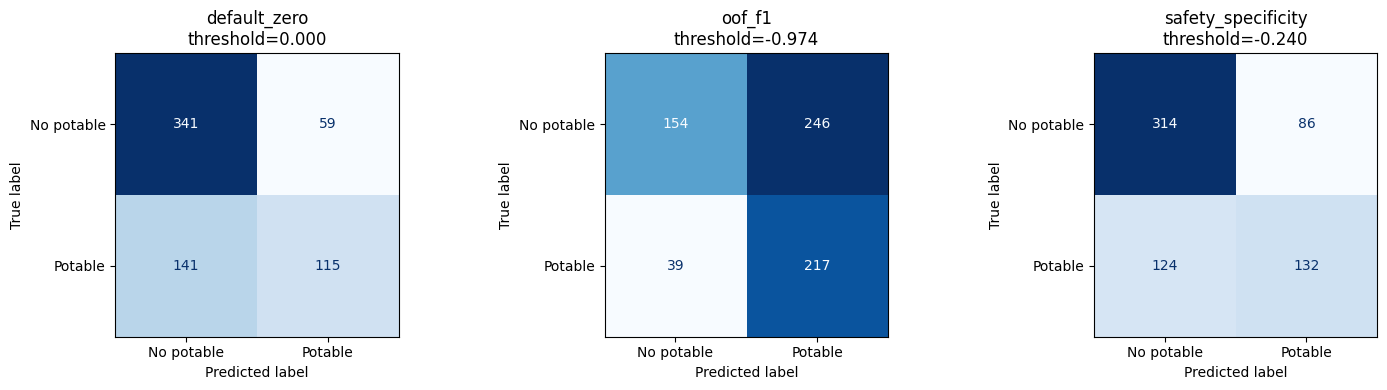

default_zero | threshold = 0.0
                precision    recall  f1-score   support

No potable (0)     0.7075    0.8525    0.7732       400
   Potable (1)     0.6609    0.4492    0.5349       256

      accuracy                         0.6951       656
     macro avg     0.6842    0.6509    0.6541       656
  weighted avg     0.6893    0.6951    0.6802       656

oof_f1 | threshold = -0.973989
                precision    recall  f1-score   support

No potable (0)     0.7979    0.3850    0.5194       400
   Potable (1)     0.4687    0.8477    0.6036       256

      accuracy                         0.5655       656
     macro avg     0.6333    0.6163    0.5615       656
  weighted avg     0.6694    0.5655    0.5523       656

safety_specificity | threshold = -0.23988
                precision    recall  f1-score   support

No potable (0)     0.7169    0.7850    0.7494       400
   Potable (1)     0.6055    0.5156    0.5570       256

      accuracy                         0.6799   

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (policy, threshold) in zip(axes, threshold_policies.items()):
    pred = (audit_scores >= threshold).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=['No potable', 'Potable'],
        cmap='Blues', colorbar=False, ax=ax,
    )
    ax.set_title(f'{policy}\nthreshold={threshold:.3f}')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'v2_confusion_matrices.png', dpi=180, bbox_inches='tight')
plt.show()

for policy, threshold in threshold_policies.items():
    print('=' * 80)
    print(policy, '| threshold =', round(threshold, 6))
    print(classification_report(
        y_test,
        (audit_scores >= threshold).astype(int),
        target_names=['No potable (0)', 'Potable (1)'],
        digits=4,
        zero_division=0,
    ))

### Interpretación de las políticas

- `default_zero`: referencia estándar de `SVC.predict()`.
- `oof_f1`: política principal si el objetivo oficial es maximizar F1.
- `safety_specificity`: exige una especificidad mínima en entrenamiento y reduce
  falsos positivos de potabilidad.

La política operacional debe declararse antes de observar cuál obtiene la mejor
métrica en test.

## 11. Auditoría del balanceo seleccionado

In [16]:
train_imputed = final_model.named_steps['imputer'].transform(X_train)
train_scaled = final_model.named_steps['scaler'].transform(train_imputed)
train_resampled, target_resampled = final_model.named_steps['sampler'].fit_resample(
    train_scaled, y_train
)
print('Antes:', Counter(y_train))
print('Después:', Counter(target_resampled))
print('Holdout original:', Counter(y_test))

Antes: Counter({0: 1598, 1: 1022})
Después: Counter({0: 1472, 1: 1189})
Holdout original: Counter({0: 400, 1: 256})


## 12. Subconjunto cuántico congelado: 64 muestras reales

Se extraen 32 muestras reales por clase desde el nuevo holdout. Se guardan:

- datos crudos;
- representación exacta del modelo V2;
- representación estricta de nueve dimensiones basada en mediana + StandardScaler.

Para una comparación clásica–cuántica estricta, ambos modelos deben usar la misma
representación, elegida antes de entrenar la QSVM.

In [17]:
idx_0 = y_test[y_test == 0].sample(n=32, random_state=QUANTUM_SEED).index
idx_1 = y_test[y_test == 1].sample(n=32, random_state=QUANTUM_SEED).index
quantum_indices = np.r_[idx_0.to_numpy(), idx_1.to_numpy()]
np.random.default_rng(QUANTUM_SEED).shuffle(quantum_indices)

X_quantum_raw = X_test.loc[quantum_indices].copy()
y_quantum = y_test.loc[quantum_indices].to_numpy(dtype=int)
assert Counter(y_quantum) == Counter({0: 32, 1: 32})

q_imputed = final_model.named_steps['imputer'].transform(X_quantum_raw)
X_quantum_model_space = final_model.named_steps['scaler'].transform(q_imputed)
try:
    model_feature_names = list(
        final_model.named_steps['imputer'].get_feature_names_out(FEATURES)
    )
except Exception:
    model_feature_names = [f'feature_{i}' for i in range(X_quantum_model_space.shape[1])]

strict_imputer = SimpleImputer(strategy='median')
strict_scaler = StandardScaler()
strict_scaler.fit(strict_imputer.fit_transform(X_train))
X_quantum_9d = strict_scaler.transform(strict_imputer.transform(X_quantum_raw))

print('Model space:', X_quantum_model_space.shape)
print('Strict 9D:', X_quantum_9d.shape)

Model space: (64, 9)
Strict 9D: (64, 9)


In [18]:
raw_export = X_quantum_raw.copy()
raw_export.insert(0, 'source_index', raw_export.index)
raw_export[TARGET] = y_quantum
raw_export.to_csv(ARTIFACT_DIR / 'quantum_subset_v2_64_raw.csv', index=False)

model_export = pd.DataFrame(X_quantum_model_space, columns=model_feature_names)
model_export.insert(0, 'source_index', quantum_indices)
model_export[TARGET] = y_quantum
model_export.to_csv(
    ARTIFACT_DIR / 'quantum_subset_v2_64_selected_model_space.csv', index=False
)

strict_export = pd.DataFrame(X_quantum_9d, columns=FEATURES)
strict_export.insert(0, 'source_index', quantum_indices)
strict_export[TARGET] = y_quantum
strict_export.to_csv(ARTIFACT_DIR / 'quantum_subset_v2_64_strict_9d.csv', index=False)

np.savez_compressed(
    ARTIFACT_DIR / 'quantum_subset_v2_64.npz',
    X_selected_model_space=X_quantum_model_space,
    X_strict_9d=X_quantum_9d,
    y=y_quantum,
    source_indices=quantum_indices,
    selected_feature_names=np.array(model_feature_names, dtype=object),
    strict_feature_names=np.array(FEATURES, dtype=object),
)
joblib.dump(
    {'imputer': strict_imputer, 'scaler': strict_scaler, 'features': FEATURES},
    ARTIFACT_DIR / 'quantum_strict_9d_preprocessor.joblib',
)

['/content/drive/MyDrive/Colab Notebooks/artifacts_v2/quantum_strict_9d_preprocessor.joblib']

## 13. Guardado del modelo y manifiesto

In [19]:
joblib.dump(final_model, ARTIFACT_DIR / 'svm_rbf_v2_selected_pipeline.joblib')

manifest = {
    'dataset_path': str(DATA_PATH),
    'dataset_shape': list(df.shape),
    'feature_order': FEATURES,
    'train_size': len(X_train),
    'audit_test_size': len(X_test),
    'audit_test_seed': AUDIT_TEST_SEED,
    'selected_trial_number': selected_trial_number,
    'selected_params': selected_params,
    'threshold_policies': threshold_policies,
    'quantum_sample_size': 64,
    'quantum_model_dimensions': list(X_quantum_model_space.shape),
    'quantum_strict_9d_dimensions': list(X_quantum_9d.shape),
    'versions': {
        'python': platform.python_version(),
        'scikit_learn': sklearn.__version__,
        'imbalanced_learn': imblearn.__version__,
        'optuna': optuna.__version__,
        'numpy': np.__version__,
        'pandas': pd.__version__,
    },
}
with open(ARTIFACT_DIR / 'v2_manifest.json', 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False, default=str)

print('Artefactos:')
for item in sorted(ARTIFACT_DIR.iterdir()):
    print('-', item.name)

Artefactos:
- audit_test_v2_locked.csv
- quantum_strict_9d_preprocessor.joblib
- quantum_subset_v2_64.npz
- quantum_subset_v2_64_raw.csv
- quantum_subset_v2_64_selected_model_space.csv
- quantum_subset_v2_64_strict_9d.csv
- svm_rbf_v2_selected_pipeline.joblib
- v2_audit_test_metrics.csv
- v2_candidate_stability_repeats.csv
- v2_candidate_summary.csv
- v2_confusion_matrices.png
- v2_manifest.json
- v2_optuna_trials.csv
- v2_selected_configuration.json
- v2_threshold_audit.csv


## 14. Reglas de reporte y transición a QSVM

El reporte debe incluir:

1. configuración seleccionada mediante entrenamiento;
2. media y desviación OOF;
3. auditoría del umbral;
4. métricas del nuevo holdout;
5. matriz de confusión;
6. diferencia entre el umbral F1 y el umbral conservador.

Antes de la Parte 2 se deben congelar los 64 índices, la representación, la
política de umbral y las métricas. No se debe seleccionar de nuevo el subconjunto
después de observar el rendimiento de la QSVM.